# Load example files for training

### For loading data you should use andothe notebook **stretch_las_to_rectangle.ipynb**

# Transformations - (Preparation Data For Training)

## Cut Las files on tiles 250x250

## Functions - cut las files

In [ ]:
import sys
sys.path.append('../../preprocessing')

from slicing_las_python import main_not_parallel_cut_tiles

## Run cutting las files

In [14]:
# Пример использования
input_directory = 'data\data_las_stretched'
output_directory = 'data\data_las_cut'
main_not_parallel_cut_tiles(input_directory, output_directory, tile_size=250, train_mode=True)

['OCCC_points.las', 'RA_points.las', 'USC_points.las', 'WMSC_points.las']
Saved data\data_las_cut\OCCC_points_0_0_0_0.las
Saved data\data_las_cut\OCCC_points_0_0_0_250.las
Saved data\data_las_cut\OCCC_points_0_0_250_0.las
Saved data\data_las_cut\OCCC_points_0_0_250_250.las
Saved data\data_las_cut\RA_points_0_0_0_0.las
Saved data\data_las_cut\RA_points_0_0_0_250.las
Saved data\data_las_cut\RA_points_0_0_250_0.las
Saved data\data_las_cut\RA_points_0_0_250_250.las
Saved data\data_las_cut\USC_points_0_0_0_0.las
Saved data\data_las_cut\USC_points_0_0_0_250.las
Saved data\data_las_cut\USC_points_0_0_250_0.las
Saved data\data_las_cut\USC_points_0_0_250_250.las
Saved data\data_las_cut\WMSC_points_0_0_0_0.las
Saved data\data_las_cut\WMSC_points_0_0_0_250.las
Saved data\data_las_cut\WMSC_points_0_0_250_0.las
Saved data\data_las_cut\WMSC_points_0_0_250_250.las


## Functions - transformation to tensors npy

In [ ]:
import sys
sys.path.append('../../preprocessing')

from transformation_las2npy import main_parallel_transform_to_tensor
from config_preprocessing import (
    M_tensor_size, K_nn, feature_input_tensor, feature_output_tensor,
    num_points_lim)


## Run tranformations to tensors

In [ ]:
import time
input_directory = 'data/data_las_cut'
output_directory = 'data/data_npy'

start = time.time()
main_parallel_transform_to_tensor(input_directory, output_directory,
                                      feature_input_tensor, feature_output_tensor,
                                      num_points_lim, M_tensor_size, K_nn)
end = time.time()
print(round((end-start)))

8
['OCCC_points_0_0_0_0.las', 'OCCC_points_0_0_0_250.las', 'OCCC_points_0_0_250_0.las', 'OCCC_points_0_0_250_250.las', 'RA_points_0_0_0_0.las', 'RA_points_0_0_0_250.las', 'RA_points_0_0_250_0.las', 'RA_points_0_0_250_250.las', 'USC_points_0_0_0_0.las', 'USC_points_0_0_0_250.las', 'USC_points_0_0_250_0.las', 'USC_points_0_0_250_250.las', 'WMSC_points_0_0_0_0.las', 'WMSC_points_0_0_0_250.las', 'WMSC_points_0_0_250_0.las', 'WMSC_points_0_0_250_250.las']
12


# Visualisation Transform - Tensors

## functions - tensor visual

In [ ]:
import sys
sys.path.append('../../preprocessing')

from image_generator import visual_tensor
from config_preprocessing import channels_visualisation, feature_output_tensor, channels_visualisation_rgb
from image_generator_class import visual_tensor_class
from config_preprocessing import class_to_color, class_to_color_multiclass

## run visualisation

In [ ]:
import time
import os
import numpy as np

start = time.time()

# Example function call
input_dir = 'data/data_npy'
output_dir_features = 'data/data_img_features'
output_dir_rgb = 'data/data_img_rgb'
output_dir_class = 'data/data_img_class'

# Create output directories if they do not exist
os.makedirs(output_dir_rgb, exist_ok=True)
os.makedirs(output_dir_features, exist_ok=True)
os.makedirs(output_dir_class, exist_ok=True)

# Get list of .npy files
filenames = [f for f in os.listdir(input_dir) if f.endswith('.npy')]
print(filenames)

for filename in filenames:
    file_path = os.path.join(input_dir, filename)
    data = np.load(file_path)  # Load

    # Call visualization functions
    visual_tensor(input_dir, filename,
                  feature_output_tensor, channels_visualisation, output_dir_features)
    visual_tensor(input_dir, filename,
                  feature_output_tensor, channels_visualisation_rgb, output_dir_rgb)
    visual_tensor_class(input_dir, filename,
                        class_to_color_multiclass,
                        output_dir_class)

end = time.time()
print(round((end - start)))


['OCCC_points_0_0_0_0.npy', 'OCCC_points_0_0_0_250.npy', 'OCCC_points_0_0_250_0.npy', 'OCCC_points_0_0_250_250.npy', 'RA_points_0_0_0_0.npy', 'RA_points_0_0_0_250.npy', 'RA_points_0_0_250_0.npy', 'RA_points_0_0_250_250.npy', 'USC_points_0_0_0_0.npy', 'USC_points_0_0_0_250.npy', 'USC_points_0_0_250_0.npy', 'USC_points_0_0_250_250.npy', 'WMSC_points_0_0_0_0.npy', 'WMSC_points_0_0_0_250.npy', 'WMSC_points_0_0_250_0.npy', 'WMSC_points_0_0_250_250.npy']
channel feature 0
255.0
0.0
channel feature 1
255.0
0.0
channel feature 2
255.0
2.8796105
channel feature 3
255.0
8.879217
channel feature 4
255.0
13.3916855
channel feature 5
255.0
6.573577
channel feature 0
255.0
0.0
channel feature 1
255.0
0.0
channel feature 2
255.0
5.5344954
channel feature 3
255.0
9.95889
channel feature 4
255.0
11.06405
channel feature 5
255.0
7.727273
channel feature 0
255.0
0.0
channel feature 1
255.0
0.0
channel feature 2
255.0
3.8141184
channel feature 3
255.0
9.322581
channel feature 4
255.0
11.777659
channel fea

## Join for visualisation

In [ ]:
import sys
sys.path.append('../../postprocessing')

from join_img import stitch_images_by_basename

input_folder_features = 'data/data_img_features'
input_folder_rgb = 'data/data_img_rgb'
input_folder_class = 'data/data_img_class'

output_folder_features = 'data/data_features_join'
output_folder_rgb = 'data/data_rgb_join'
output_folder_class = 'data/data_class_join'


stitch_images_by_basename(input_folder_features, output_folder_features)
stitch_images_by_basename(input_folder_rgb, output_folder_rgb)
stitch_images_by_basename(input_folder_class, output_folder_class)

Found 4 basename groups:
  OCCC: 4 files
  RA: 4 files
  USC: 4 files
  WMSC: 4 files

Processing basename: OCCC


Stitching OCCC: 100%|██████████| 2/2 [00:00<00:00,  8.92it/s]


Saved joined image for OCCC: data/data_features_join\OCCC_joined.png

Processing basename: RA


Stitching RA: 100%|██████████| 2/2 [00:00<00:00, 18.11it/s]


Saved joined image for RA: data/data_features_join\RA_joined.png

Processing basename: USC


...

Saved joined image for RA: data/data_class_join\RA_joined.png

Processing basename: USC


Stitching USC: 100%|██████████| 2/2 [00:00<00:00, 12.62it/s]


Saved joined image for USC: data/data_class_join\USC_joined.png

Processing basename: WMSC


Stitching WMSC: 100%|██████████| 2/2 [00:00<00:00, 14.18it/s]


Saved joined image for WMSC: data/data_class_join\WMSC_joined.png

Completed stitching for all basename groups in data/data_class_join


## Conclusions after Transformations

Now we have ready data for training.


We will use for input data images wich generated from x,y,z the features $z_{mean}, n_r, n_z$ This parameters described in manual


For output we will use images with classes

# Model training

## Load data for training

## Functions for load data

In [ ]:
import os
from pathlib import Path
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torch.optim as optim
from sklearn.metrics import confusion_matrix

# === Set Up Map color to class ===
class_to_color = class_to_color_multiclass

color_to_class = {tuple(v): k for k, v in class_to_color.items()}

def rgb_to_class(mask_array, color_to_class):
    h, w, _ = mask_array.shape
    class_mask = np.zeros((h, w), dtype=np.uint8)
    for color, class_idx in color_to_class.items():
        matches = np.all(mask_array == color, axis=-1)
        class_mask[matches] = class_idx
    return class_mask

class ImageMaskDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform
        self.image_filenames = sorted(self.image_dir.glob("*.png"))

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        image_path = self.image_filenames[idx]
        mask_path = self.mask_dir / image_path.name
        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("RGB")
        mask_np = np.array(mask)
        mask_class = rgb_to_class(mask_np, color_to_class)
        if self.transform:
            image = self.transform(image)
        mask_tensor = torch.from_numpy(mask_class).long()
        return image, mask_tensor

def get_dataloaders(image_dir, mask_dir, train_ratio=0.8, batch_size=8):
    transform = T.Compose([T.ToTensor()])
    dataset = ImageMaskDataset(image_dir, mask_dir, transform)
    train_size = int(train_ratio * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

## load data

In [ ]:
org = 'data_img_features'
seg = 'data_img_class'

train_loader, val_loader = get_dataloaders(org, seg, train_ratio=0.8, batch_size=8)

## Install pytorch models

### for training Nvidia videocard is needed

In [ ]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 123.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 44.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

## Training model functions

In [ ]:
import csv


def evaluate_model(model, data_loader, criterion, device, num_classes):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, masks in data_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)  # (B, C, H, W)
            loss = criterion(outputs, masks)
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)  # (B, H, W)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(masks.cpu().numpy())
    preds_flat = np.concatenate([p.flatten() for p in all_preds])
    labels_flat = np.concatenate([l.flatten() for l in all_labels])
    conf_matrix = confusion_matrix(labels_flat, preds_flat, labels=range(num_classes))
    return total_loss / len(data_loader), conf_matrix

def compute_metrics(conf_matrix, class_idx):
    TP = conf_matrix[class_idx, class_idx]
    FP = conf_matrix[:, class_idx].sum() - TP
    FN = conf_matrix[class_idx, :].sum() - TP
    TN = conf_matrix.sum() - (TP + FP + FN)

    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    iou = TP / (TP + FP + FN + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return precision, recall, iou, f1

def print_metrics(conf_matrix, split_name, num_classes):
    precisions = []
    recalls = []
    min_vals = []
    for i in range(num_classes):
        TP = conf_matrix[i, i]
        FP = conf_matrix[:, i].sum() - TP
        FN = conf_matrix[i, :].sum() - TP
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        precisions.append(precision)
        recalls.append(recall)
        min_val = min(precision, recall)
        min_vals.append(min_val)
        print(f"[{split_name}] Class {i:2d}: Precision={precision:.4f}, Recall={recall:.4f}, Min={min_val:.4f}")
    formatted_min_vals = [f"{v:.4f}" for v in min_vals]
    print(f"[{split_name}] Min(Precision, Recall) per class: [{', '.join(formatted_min_vals)}]")

def train_model(model, train_loader, val_loader, num_epochs=10, device="cuda"):
    model.to(device)
    criterion = smp.losses.DiceLoss("multiclass")
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    checkpoint_dir = "checkpoints_multiclass_metrics"
    os.makedirs(checkpoint_dir, exist_ok=True)
    num_classes = len(class_to_color)

    # Prepare CSV file for logging metrics
    metrics_csv_path = os.path.join(checkpoint_dir, "metrics_log.csv")
    with open(metrics_csv_path, mode="w", newline="") as csv_file:
        writer = csv.writer(csv_file)
        writer.writerow(["epoch", "dataset", "class", "precision", "recall", "iou", "f1"])

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)  # (B, C, H, W)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Save checkpoint
        torch.save(model.state_dict(), os.path.join(checkpoint_dir, f"model_epoch_{epoch + 1}.pth"))

        # Evaluate on validation and training sets
        val_loss, val_conf_matrix = evaluate_model(model, val_loader, criterion, device, num_classes)
        train_eval_loss, train_conf_matrix = evaluate_model(model, train_loader, criterion, device, num_classes)

        # Print and save metrics
        print_metrics(train_conf_matrix, "Train", num_classes)
        print_metrics(val_conf_matrix, "Val", num_classes)

        # Save metrics to CSV
        with open(metrics_csv_path, mode="a", newline="") as csv_file:
            writer = csv.writer(csv_file)

            for cls in range(num_classes):
                train_metrics = compute_metrics(train_conf_matrix, cls)
                val_metrics = compute_metrics(val_conf_matrix, cls)

                writer.writerow([epoch + 1, "Train", cls, *train_metrics])
                writer.writerow([epoch + 1, "Val", cls, *val_metrics])

        # Print losses
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss:.4f}")

## Run training

In [ ]:
import segmentation_models_pytorch as smp

num_classes = len(class_to_color_multiclass)
model = smp.Unet(encoder_name="resnet34", in_channels=3, classes=num_classes)
train_model(model, train_loader, val_loader, num_epochs=100, device="cuda")

[Train] Class  0: Precision=0.1158, Recall=0.0172, Min=0.0172
[Train] Class  1: Precision=0.2620, Recall=0.0192, Min=0.0192
[Train] Class  2: Precision=0.0137, Recall=0.0001, Min=0.0001
[Train] Class  3: Precision=0.0000, Recall=0.0000, Min=0.0000
[Train] Class  4: Precision=0.1717, Recall=0.0014, Min=0.0014
[Train] Class  5: Precision=0.0088, Recall=0.0070, Min=0.0070
[Train] Class  6: Precision=0.0088, Recall=0.0007, Min=0.0007
[Train] Class  7: Precision=0.0009, Recall=0.0104, Min=0.0009
[Train] Class  8: Precision=0.0018, Recall=0.0004, Min=0.0004
[Train] Class  9: Precision=0.0000, Recall=0.0000, Min=0.0000
[Train] Class 10: Precision=0.0015, Recall=0.5427, Min=0.0015
[Train] Class 11: Precision=0.0000, Recall=0.0000, Min=0.0000
[Train] Class 12: Precision=0.0033, Recall=0.0038, Min=0.0033
[Train] Class 13: Precision=0.0000, Recall=0.0000, Min=0.0000
[Train] Class 14: Precision=0.0261, Recall=0.0007, Min=0.0007
[Train] Class 15: Precision=0.1692, Recall=0.2806, Min=0.1692
[Train] 

## Metrics visualisation

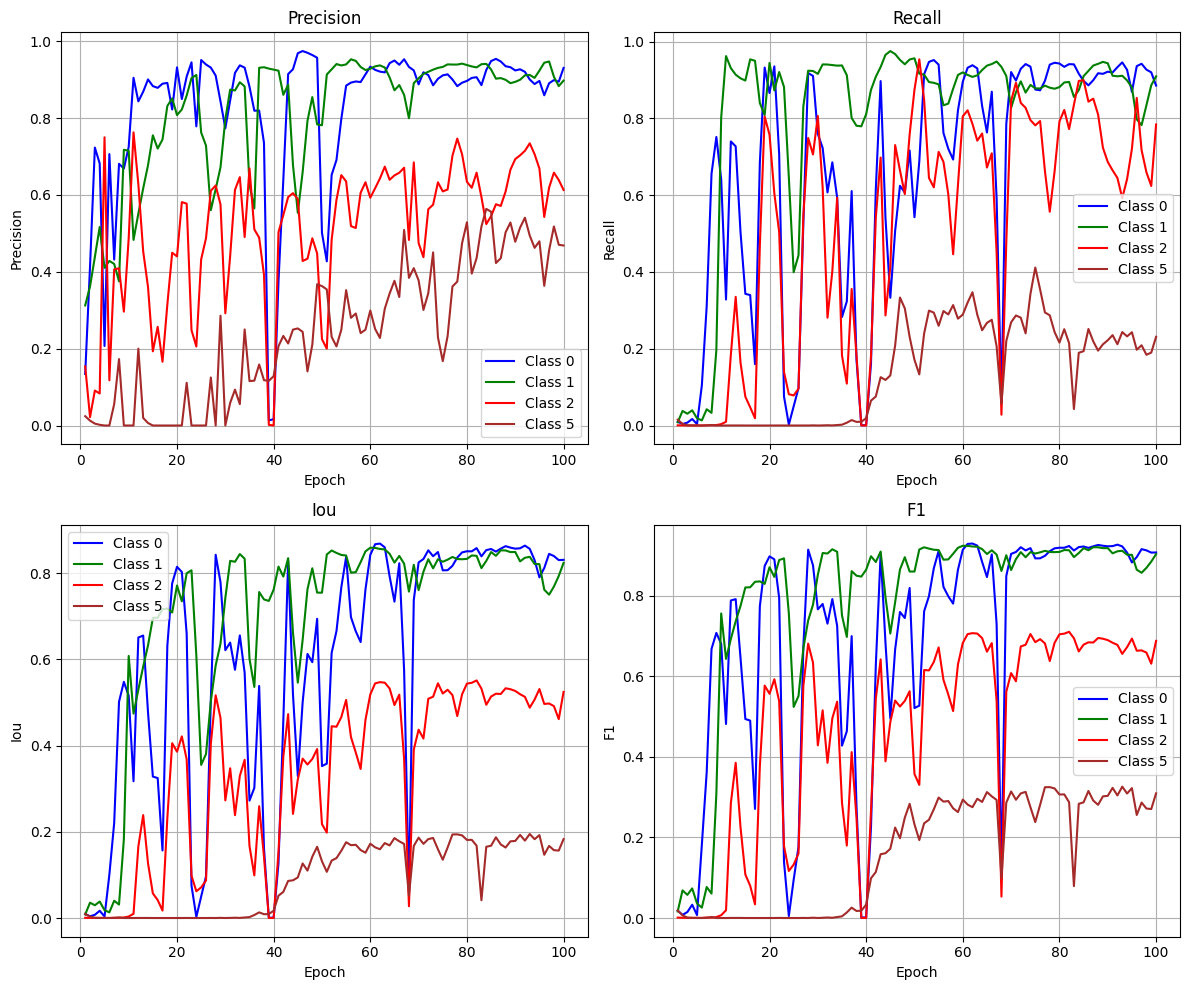

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load metrics from CSV
# csv_path = "checkpoints_multiclass_metrics/metrics_log.csv"
csv_path = "metrics_log.csv"
df = pd.read_csv(csv_path)

# Filter only validation data (if needed)
df = df[df['dataset'] == 'Val']

# Select classes to display
selected_classes = [0, 1, 2, 5]  # replace with your classes

# Configure plots
metrics = ['precision', 'recall', 'iou', 'f1']
colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown', 'pink', 'gray']

plt.figure(figsize=(12, 10))

for i, metric in enumerate(metrics):
    plt.subplot(2, 2, i + 1)
    for class_id in selected_classes:
        class_data = df[df['class'] == class_id]
        plt.plot(class_data['epoch'], class_data[metric], label=f'Class {class_id}', color=colors[class_id % len(colors)])
    plt.title(metric.capitalize())
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()